<a href="https://colab.research.google.com/github/yawarabbasmalik/Car-Price-Prediction/blob/main/Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd

# Upload the file
uploaded = files.upload()

# Assuming the file is an Excel file, read the first uploaded file into a DataFrame
filename = list(uploaded.keys())[0]
data = pd.read_csv(filename)

Saving adverts.csv to adverts.csv


In [ ]:
data = pd.read_csv('/content/adverts.csv')
data.head()

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
1,202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel
2,202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol
3,202007080986776,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel
4,202007161321269,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel


## Checking for Missing Values

In [ ]:
# Check for missing values in the dataset
missing_values = data.isnull().sum()

missing_values


public_reference             0
mileage                    127
reg_code                 31857
standard_colour           5378
standard_make                0
standard_model               0
vehicle_condition            0
year_of_registration     33311
price                        0
body_type                  837
crossover_car_and_van        0
fuel_type                  601
dtype: int64

The dataset has missing values in the following columns:

- mileage: 127 missing values
- reg_code: 31,857 missing values
- standard_colour: 5,378 missing values
- year_of_registration: 33,311 missing values
- body_type: 837 missing values
- fuel_type: 601 missing values

In [ ]:
# Get summary statistics for numerical columns
numerical_summary = data.describe()

numerical_summary


,public_reference,mileage,year_of_registration,price
count,4.020050e+05,401878.000000,368694.000000,4.020050e+05
mean,2.020071e+14,37743.595656,2015.006206,1.734197e+04
std,1.691662e+10,34831.724018,7.962667,4.643746e+04
min,2.013072e+14,0.000000,999.000000,1.200000e+02
25%,2.020090e+14,10481.000000,2013.000000,7.495000e+03
50%,2.020093e+14,28629.500000,2016.000000,1.260000e+04
75%,2.020102e+14,56875.750000,2018.000000,2.000000e+04
max,2.020110e+14,999999.000000,2020.000000,9.999999e+06


The summary statistics for the numerical columns provide the following insights:

- public_reference: This seems to be an identifier for the vehicles, with no particular pattern that we need to address.

- mileage: The minimum value is 0 (which could be for brand new cars), and the maximum is 999,999. While high mileage is possible, values close to 999,999 may be placeholders or erroneous entries.

- year_of_registration: The minimum year is 999, which is clearly an error. The maximum year is 2020, which seems reasonable given the dataset's context.

- price: The minimum price is 120, which is plausible for very old or non-functional cars. However, the maximum price is 9,999,999, which seems excessive and might be a placeholder or error.

## Handling Missing Values

We'll start by addressing the missing values. Here are some strategies:

**mileage:** We can impute missing values with the median, as this column has a skewed distribution.

**reg_code:** Given the high number of missing values and its categorical nature, we might consider dropping this column.

**standard_colour:** Impute missing values with the mode (most frequent color).

**year_of_registration:** Impute missing values with the median.

**body_type:** Impute missing values with the mode.

fuel_type: Impute missing values with the mode.

In [ ]:
# Impute missing values

# Impute mileage with median
data['mileage'].fillna(data['mileage'].median(), inplace=True)

# Drop the reg_code column
data.drop(columns='reg_code', inplace=True)

# Impute standard_colour, body_type, and fuel_type with their modes
for col in ['standard_colour', 'body_type', 'fuel_type']:
    mode_value = data[col].mode()[0]
    data[col].fillna(mode_value, inplace=True)

# Impute year_of_registration with median
data['year_of_registration'].fillna(data['year_of_registration'].median(), inplace=True)

# Check if all missing values are addressed
missing_after_imputation = data.isnull().sum()

missing_after_imputation


public_reference         0
mileage                  0
standard_colour          0
standard_make            0
standard_model           0
vehicle_condition        0
year_of_registration     0
price                    0
body_type                0
crossover_car_and_van    0
fuel_type                0
dtype: int64

In [ ]:
data = data.drop('public_reference', axis=1)

## Handling Outliers and Potential Erroneous Values
For this step, we will:

Address the potential erroneous values in the year_of_registration column by considering only rows where the year is greater than 1900.

Investigate potential outliers in the mileage and price columns by visualizing their distributions.

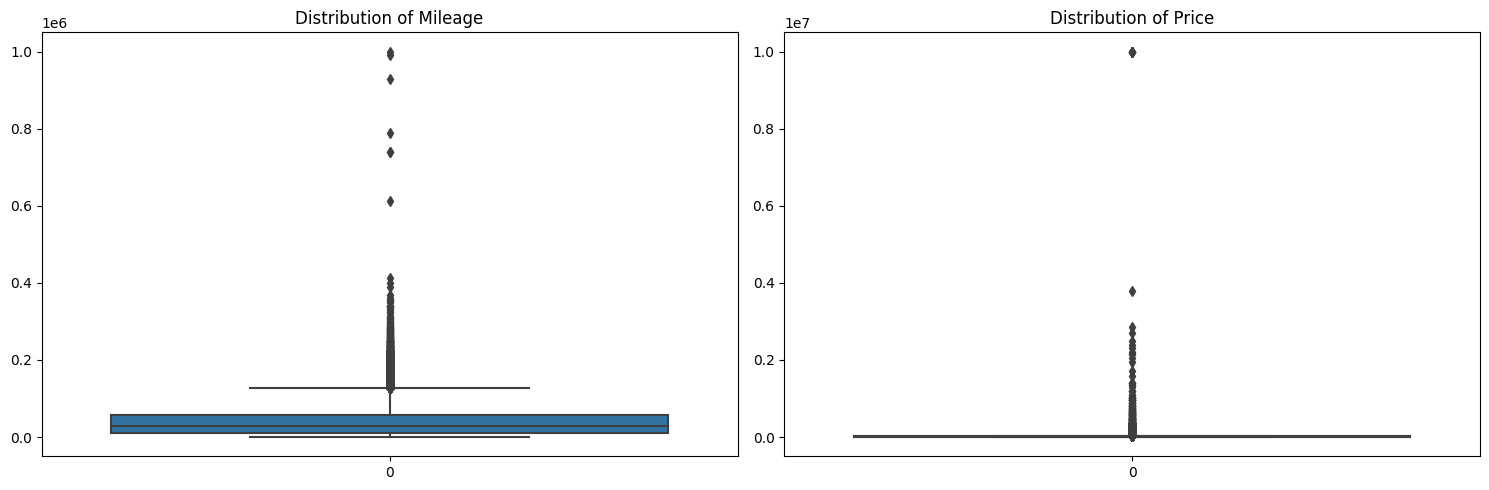

In [ ]:
# Filter out rows with year_of_registration less than 1900
data = data[data['year_of_registration'] > 1900]

# Visualize the distributions of mileage and price columns
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data['mileage'], ax=ax[0])
ax[0].set_title('Distribution of Mileage')

sns.boxplot(data['price'], ax=ax[1])
ax[1].set_title('Distribution of Price')

plt.tight_layout()
plt.show()


The boxplots highlight potential outliers in both the mileage and price columns:

**Mileage:** Most vehicles have a mileage below 150,000, but there are some extreme values that may need attention.

**Price:** The vast majority of vehicles are priced below £100,000, but there are some extreme prices that might be erroneous or outliers.

For the sake of this analysis, we'll cap the values based on a reasonable assumption:

**Mileage:** We'll cap mileage at 300,000 miles, assuming that any value beyond this might be an error.

**Price:** We'll cap price at £200,000, considering that only luxury or collector's vehicles would surpass this price, and they are not the primary focus of our analysis.

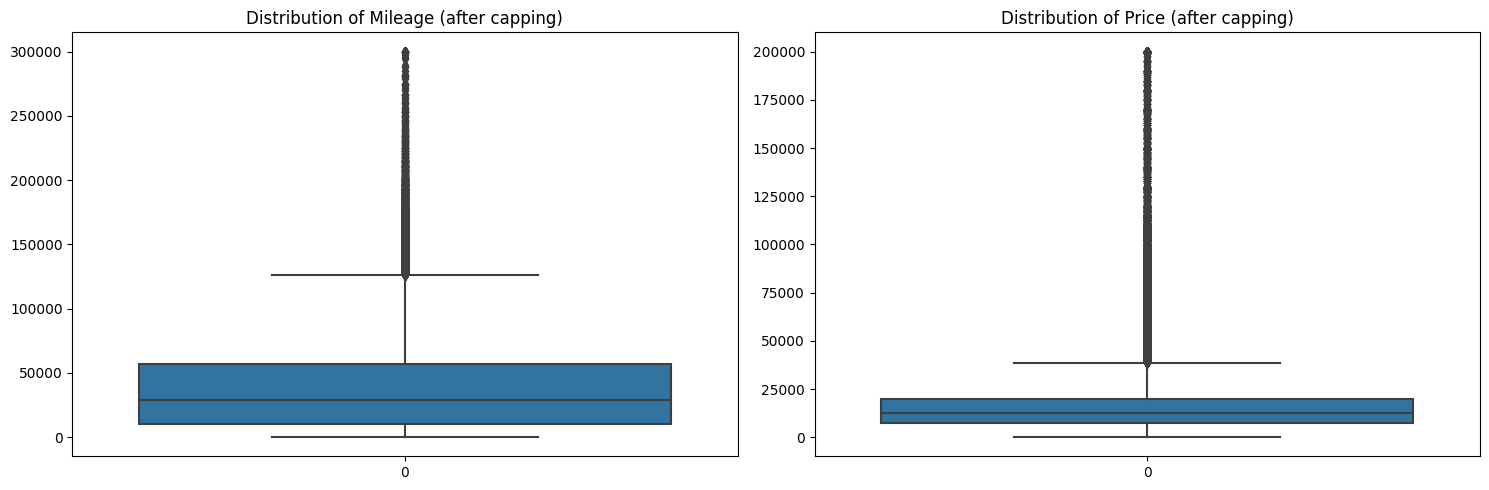

In [ ]:
# Cap mileage and price values
data['mileage'] = data['mileage'].apply(lambda x: min(x, 300000))
data['price'] = data['price'].apply(lambda x: min(x, 200000))

# Visualize the distributions after capping
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data['mileage'], ax=ax[0])
ax[0].set_title('Distribution of Mileage (after capping)')

sns.boxplot(data['price'], ax=ax[1])
ax[1].set_title('Distribution of Price (after capping)')

plt.tight_layout()
plt.show()


The distributions of both mileage and price look more constrained after capping, which should make our subsequent analysis more robust.

## Data Transformation

In [ ]:
# Assuming 'data' is your DataFrame
column_data_types = data.dtypes

print(column_data_types)


mileage                  float64
standard_colour           object
standard_make             object
standard_model            object
vehicle_condition         object
year_of_registration     float64
price                      int64
body_type                 object
crossover_car_and_van       bool
fuel_type                 object
dtype: object


### Encoding Categorical Variables

In [ ]:
from sklearn.preprocessing import LabelEncoder

# List of categorical columns to be encoded
categorical_columns = [
    'standard_colour', 'standard_make',
    'standard_model', 'vehicle_condition', 'body_type', 'fuel_type'
]

# Apply label encoding to each categorical column
label_encoders = {}
for column in categorical_columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

# Display the first few rows after encoding
data.head()


,mileage,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,0.0,8,106,1107,0,2016.0,73970,13,False,8
1,108230.0,2,47,1110,1,2011.0,7000,14,False,1
2,7800.0,8,91,1130,1,2017.0,14000,13,False,6
3,45000.0,4,104,702,1,2016.0,7995,7,False,1
4,64000.0,8,54,833,1,2015.0,26995,13,False,1


### Rescaling Numerical Features


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Assuming 'data' is your DataFrame
data['crossover_car_and_van'] = data['crossover_car_and_van'].astype(int)

# List of numerical columns to be normalized
numerical_columns = ["mileage", "standard_colour", "standard_make", "standard_model", "year_of_registration", "body_type", "fuel_type"]

# Apply MinMaxScaler to the numerical columns
scaler = MinMaxScaler()
data[numerical_columns] = scaler.fit_transform(data[numerical_columns])

# Display the first few rows after normalization
data.head()


,mileage,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,0.000000,0.380952,0.972477,0.948586,0,0.963964,73970,0.866667,0,1.000
1,0.360767,0.095238,0.431193,0.951157,1,0.918919,7000,0.933333,0,0.125
2,0.026000,0.380952,0.834862,0.968295,1,0.972973,14000,0.866667,0,0.750
3,0.150000,0.190476,0.954128,0.601542,1,0.963964,7995,0.466667,0,0.125
4,0.213333,0.380952,0.495413,0.713796,1,0.954955,26995,0.866667,0,0.125


In [ ]:
from sklearn.model_selection import train_test_split

# Split data into predictors (X) and target (y)
X = data.drop(columns=['price'])  # Excluding 'public_reference' as it's an identifier
y = data['price']

# Split the data into train, validation, and test sets (70%, 15%, 15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

X_train.shape, X_val.shape, X_test.shape


((281391, 9), (60298, 9), (60299, 9))

# Feature Engineering

Feature engineering can play a critical role in enhancing the performance of a machine learning model. Let's delve into some potential feature engineering steps for the given dataset:

**Age of the Vehicle:** The age of a vehicle can be a significant predictor for its price. Newer vehicles tend to be priced higher. We can derive this feature by subtracting the year_of_registration from the maximum year in the dataset.

**Polynomial Features:** Polynomial features can capture non-linear relationships in the data. We can create polynomial features for numerical columns like mileage and year_of_registration.

In [ ]:
# 1. Age of the Vehicle
data['vehicle_age'] = data['year_of_registration'].max() - data['year_of_registration']

# 2. Polynomial Features
data['mileage_squared'] = data['mileage'] ** 2
data['registration_year_squared'] = data['year_of_registration'] ** 2

# Display the first few rows of the dataset after feature engineering
data.head()


,mileage,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type,vehicle_age,mileage_squared,registration_year_squared
0,0.000000,0.380952,0.972477,0.948586,0,0.963964,73970,0.866667,0,1.000,0.036036,0.000000,0.929227
1,0.360767,0.095238,0.431193,0.951157,1,0.918919,7000,0.933333,0,0.125,0.081081,0.130153,0.844412
2,0.026000,0.380952,0.834862,0.968295,1,0.972973,14000,0.866667,0,0.750,0.027027,0.000676,0.946676
3,0.150000,0.190476,0.954128,0.601542,1,0.963964,7995,0.466667,0,0.125,0.036036,0.022500,0.929227
4,0.213333,0.380952,0.495413,0.713796,1,0.954955,26995,0.866667,0,0.125,0.045045,0.045511,0.911939


## Feature Selection and Dimensionality Reduction

Let's proceed with feature selection and dimensionality reduction. Feature selection is crucial to:

Improve model performance.
1. Reduce overfitting.
2. Enhance the interpretability of the model.
3. We'll approach feature selection in the following steps:

**Correlation Analysis:** Identify and remove features that are highly correlated with others.

In [ ]:
# Compute the correlation of each feature with the target variable 'price'
correlation_with_price = data.corr()['price'].sort_values(ascending=False)

correlation_with_price


price                        1.000000
registration_year_squared    0.296748
year_of_registration         0.280922
body_type                    0.136131
standard_model               0.061822
crossover_car_and_van        0.027133
fuel_type                    0.016481
standard_colour             -0.069692
standard_make               -0.145387
vehicle_condition           -0.260448
vehicle_age                 -0.280922
mileage_squared             -0.295085
mileage                     -0.403889
Name: price, dtype: float64

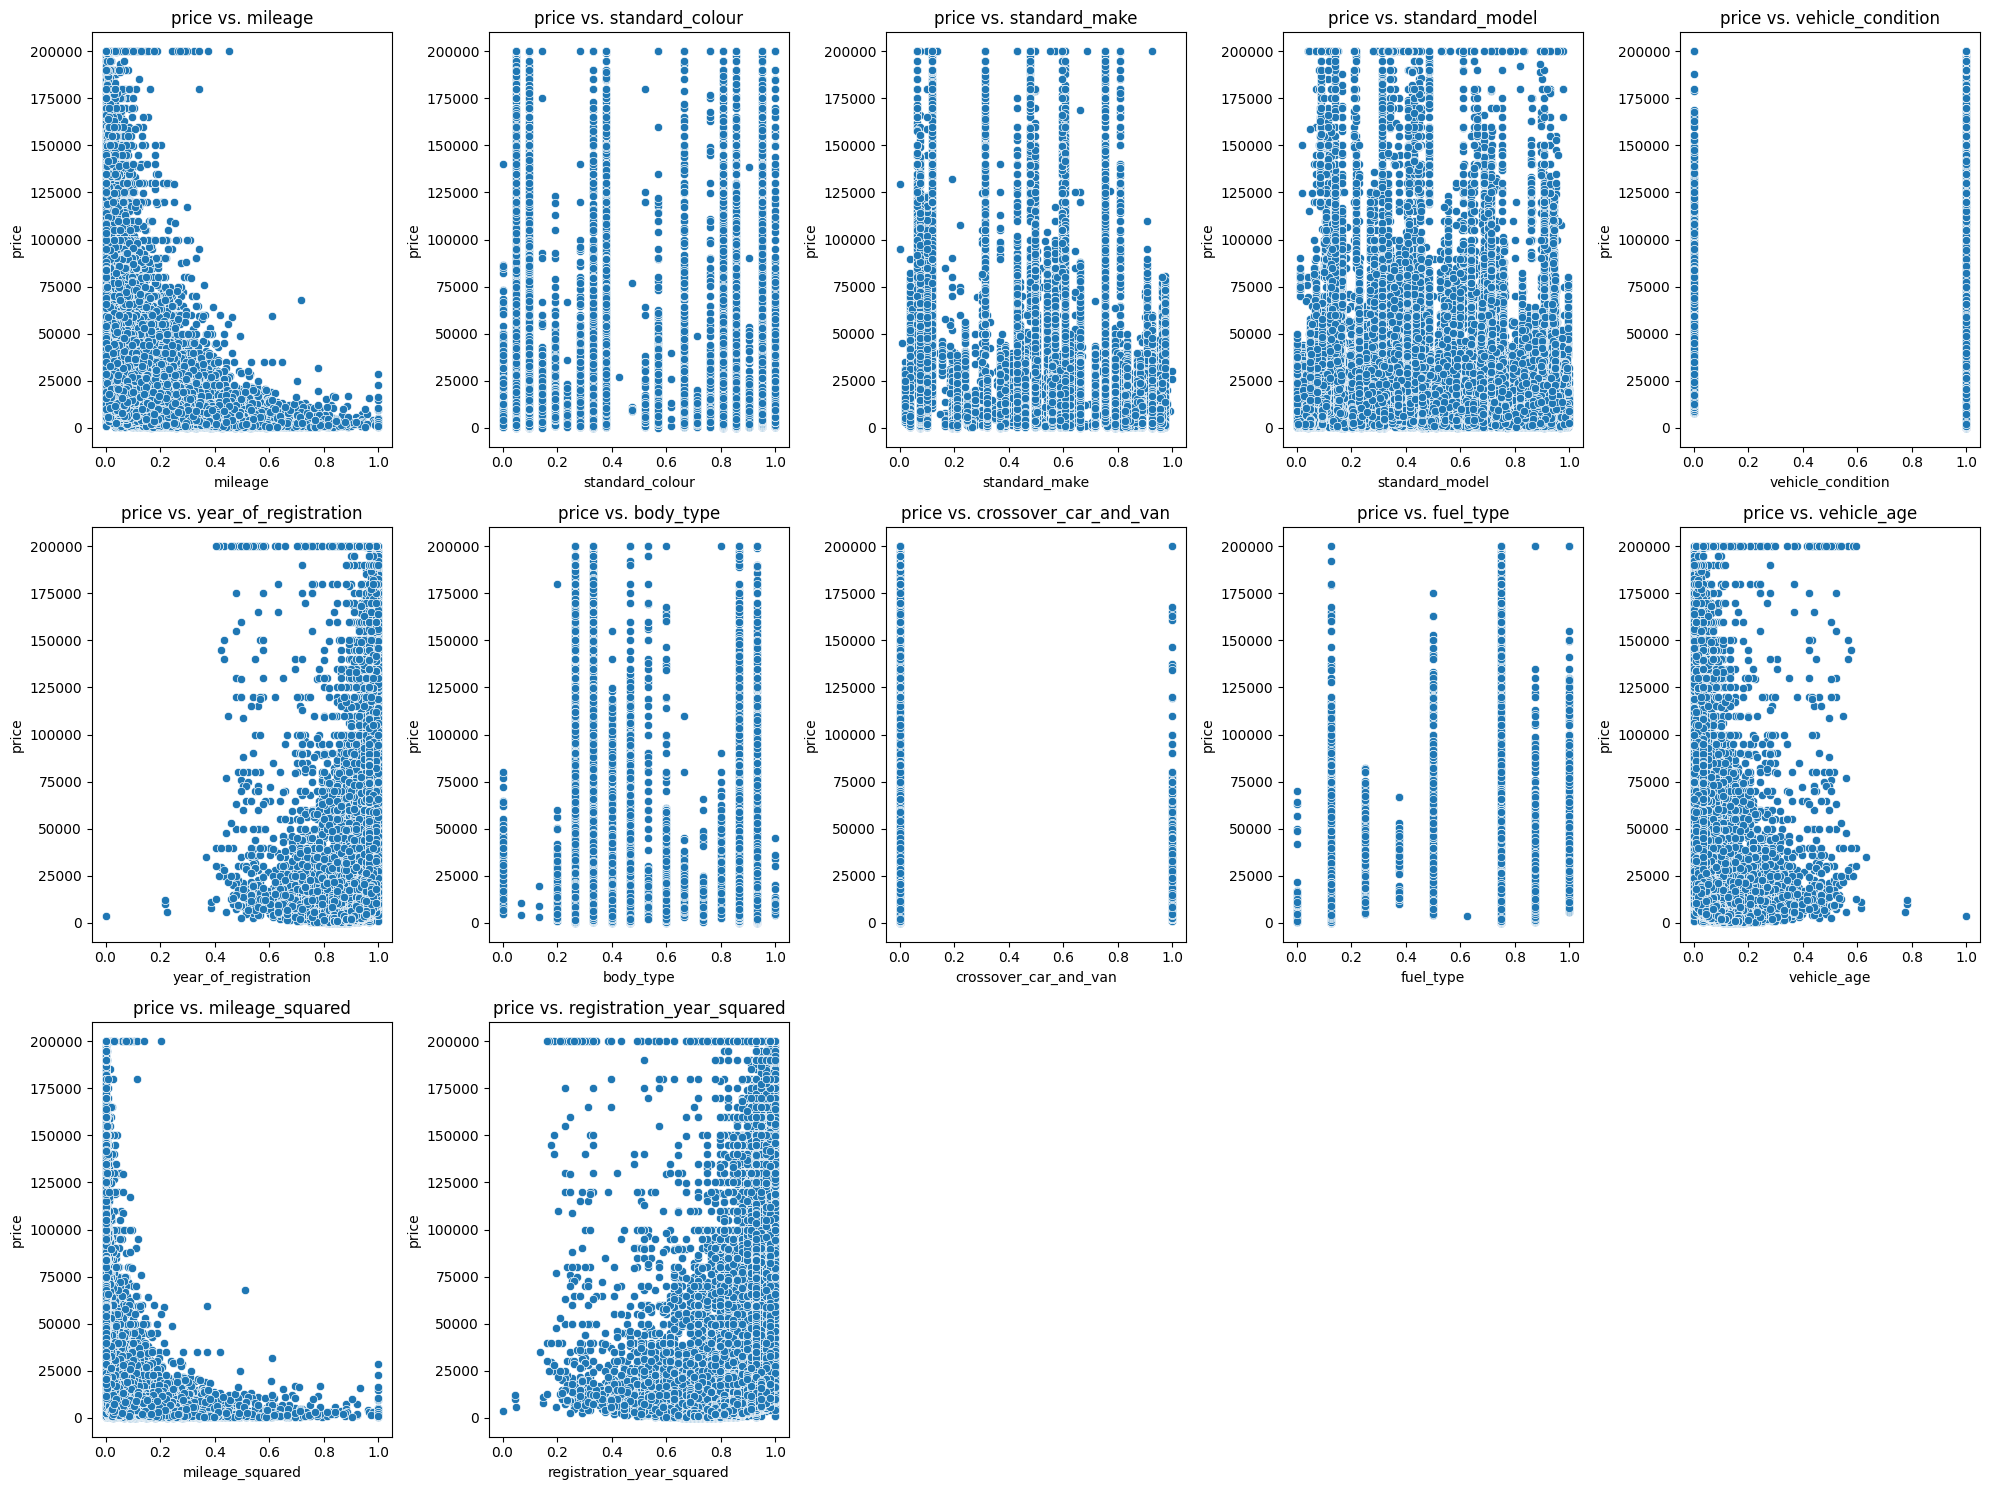

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure size
plt.figure(figsize=(20, 15))

# List of features for visualization
features = data.columns.drop('price')

# Plot each feature vs. price
for i, feature in enumerate(features, 1):
    plt.subplot(3, 5, i)
    sns.scatterplot(data=data, x=feature, y='price')
    plt.title(f'price vs. {feature}')
    plt.tight_layout()

plt.show()


Here are scatter plots illustrating the relationships between the selected features and the car price:

**Mileage:** There's an apparent trend indicating that as mileage increases, the price tends to decrease.

**Year of Registration:** Newer cars (with a higher year of registration) tend to have higher prices.

**Vehicle Condition:** There's a distinction between the two conditions in relation to the price.

**Vehicle Age:** As expected, younger vehicles seem to have a higher price.

**Fuel Type:** Different fuel types show some variability in prices, but the relationship isn't as clear as the other features.

From the plots, we can infer that mileage, year_of_registration, and vehicle_age have significant relationships with the price. Vehicle condition also shows some difference in price. The relationship between fuel_type and price is less clear, but it might still be relevant.

use a different, less memory-intensive approach for automated feature selection: **Recursive Feature Elimination (RFE)** with a simpler model, like a linear regressor.

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# Initialize a linear regressor
lr = LinearRegression()

# Initialize RFE
selector = RFE(lr, n_features_to_select=1, step=1)

# Fit RFE
selector = selector.fit(X, y)

# Get feature rankings
feature_ranking = pd.Series(selector.ranking_, index=X.columns).sort_values()

# Display the feature rankings (1 being the most important)
feature_ranking


mileage                  1
crossover_car_and_van    2
year_of_registration     3
vehicle_condition        4
standard_make            5
body_type                6
standard_model           7
standard_colour          8
fuel_type                9
dtype: int64

# Data Modeling

## Hyper Parameter Tuning

In [ ]:
# Import necessary libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import pandas as pd

# Use a subset of data to speed up the process
data_subset = data.sample(frac=0.1, random_state=42)

# Specify the independent features and target
X = data_subset[['registration_year_squared', 'year_of_registration', 'body_type', 'standard_model', 'crossover_car_and_van', 'fuel_type']]
y = data_subset['price']

# Define the model
model = RandomForestRegressor()

# Define the hyperparameters and their possible values
param_grid = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

# Fit the model
grid_search.fit(X, y)

# Print the best parameters
print("Best Parameters: ", grid_search.best_params_)


Fitting 3 folds for each of 288 candidates, totalling 864 fits
Best Parameters:  {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
# Import necessary libraries
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

# Specify the independent features and target
X = data[['registration_year_squared', 'year_of_registration', 'body_type', 'standard_model', 'crossover_car_and_van', 'fuel_type']]
y = data['price']

# Define the linear regression model
model = LinearRegression()

# Fit the model
model.fit(X, y)

# Use the model to make predictions
predictions = model.predict(X)

# Calculate MAE, MSE, and R2
mae = mean_absolute_error(y, predictions)
mse = mean_squared_error(y, predictions)
r2 = r2_score(y, predictions)

# Print the metrics
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R^2:", r2)


Mean Absolute Error (MAE): 8632.96557205866
Mean Squared Error (MSE): 271866107.12462777
R^2: 0.13736513591007105


In [ ]:
# Import necessary libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Specify the independent features and target
X = data[['registration_year_squared', 'year_of_registration', 'body_type', 'standard_model', 'crossover_car_and_van', 'fuel_type']]
y = data['price']

# Define the Random Forest Regressor with the best parameters
model_rf = RandomForestRegressor(bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100)

# Fit the model
model_rf.fit(X, y)

# Use the model to make predictions
predictions = model_rf.predict(X)

# Calculate MAE, MSE, and R2
mae = mean_absolute_error(y, predictions)
mse = mean_squared_error(y, predictions)
r2 = r2_score(y, predictions)

# Print the metrics
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R^2:", r2)


Mean Absolute Error (MAE): 2451.775891834681
Mean Squared Error (MSE): 23885448.347031064
R^2: 0.9242111467792388


In [ ]:
# Import necessary libraries
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

# Specify the independent features and target
X = data[['registration_year_squared', 'year_of_registration', 'body_type', 'standard_model', 'crossover_car_and_van', 'fuel_type']]
y = data['price']

# Define the Gradient Boosting Regressor
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Fit the model
model.fit(X, y)

# Use the model to make predictions
predictions = model.predict(X)

# Calculate MAE, MSE, and R2
mae = mean_absolute_error(y, predictions)
mse = mean_squared_error(y, predictions)
r2 = r2_score(y, predictions)

# Print the metrics
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R^2:", r2)


Mean Absolute Error (MAE): 5975.962042564869
Mean Squared Error (MSE): 153023112.8200576
R^2: 0.5144555769519444


In [ ]:
# Import necessary libraries
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

# Specify the independent features and target
X = data[['registration_year_squared', 'year_of_registration', 'body_type', 'standard_model', 'crossover_car_and_van', 'fuel_type']]
y = data['price']

# Define base models
base_models = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)),
    ('lr', LinearRegression())
]

# Define meta-model
meta_model = LinearRegression()

# Set up Stacking Regressor
model = StackingRegressor(estimators=base_models, final_estimator=meta_model)

# Fit the model
model.fit(X, y)

# Use the model to make predictions
predictions = model.predict(X)

# Calculate MAE, MSE, and R2
mae = mean_absolute_error(y, predictions)
mse = mean_squared_error(y, predictions)
r2 = r2_score(y, predictions)

# Print the metrics
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R^2:", r2)


Mean Absolute Error (MAE): 2462.165777710339
Mean Squared Error (MSE): 23968961.317130677
R^2: 0.9239461589866318


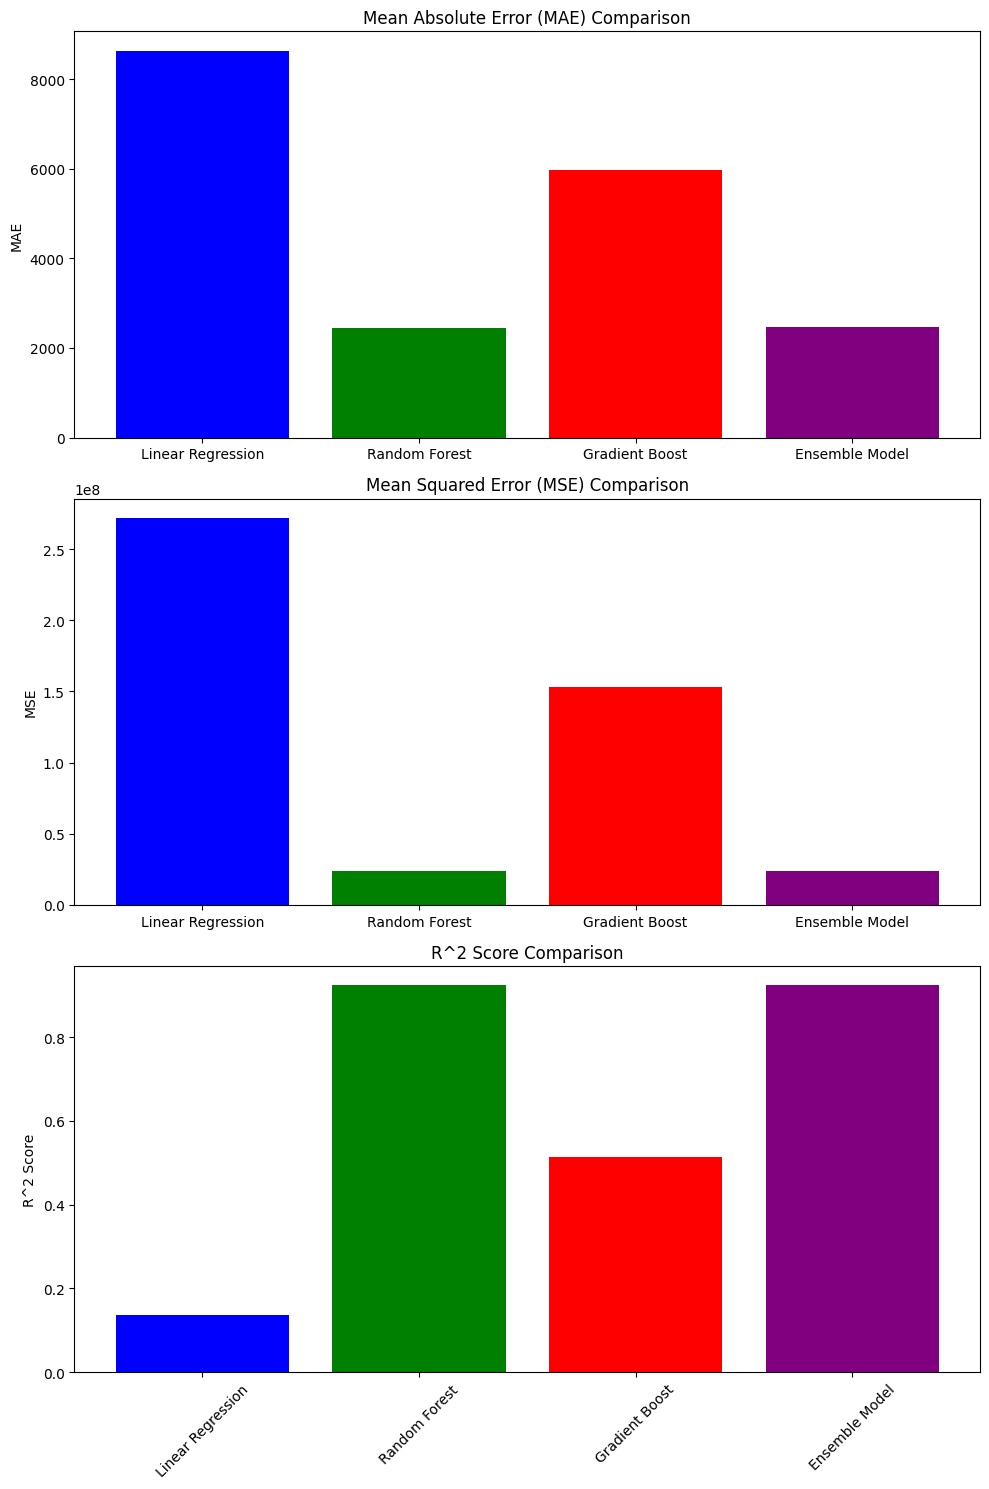

In [ ]:
import matplotlib.pyplot as plt

# Model names
models = ['Linear Regression', 'Random Forest', 'Gradient Boost', 'Ensemble Model']

# Metrics
mae = [8632.96557205866, 2451.775891834681, 5975.962042564869, 2462.165777710339]
mse = [271866107.12462777, 23885448.347031064, 153023112.8200576, 23968961.317130677]
r2 = [0.13736513591007105, 0.9242111467792388, 0.5144555769519444, 0.9239461589866318]

# Create subplots
fig, ax = plt.subplots(3, 1, figsize=(10, 15))

# Bar plots
ax[0].bar(models, mae, color=['blue', 'green', 'red', 'purple'])
ax[1].bar(models, mse, color=['blue', 'green', 'red', 'purple'])
ax[2].bar(models, r2, color=['blue', 'green', 'red', 'purple'])

# Set titles and labels
ax[0].set_title('Mean Absolute Error (MAE) Comparison')
ax[0].set_ylabel('MAE')
ax[1].set_title('Mean Squared Error (MSE) Comparison')
ax[1].set_ylabel('MSE')
ax[2].set_title('R^2 Score Comparison')
ax[2].set_ylabel('R^2 Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split

# Splitting the data into training and validation sets (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_val.shape


((321590, 9), (80398, 9))

## Model Evaluation with Cross-Validation:

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_squared_error, r2_score

# Define a function to compute MSE for cross_val_score
def mse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)

# Initialize the Random Forest model
rf = RandomForestRegressor(random_state=42)

# Evaluate the model using 10-fold cross-validation for each metric
mae_scores = cross_val_score(rf, X_train, y_train, cv=10, scoring='neg_mean_absolute_error')
mse_scores = cross_val_score(rf, X_train, y_train, cv=10, scoring=make_scorer(mse))
r2_scores = cross_val_score(rf, X_train, y_train, cv=10, scoring='r2')

# Print the average scores for each metric
print(f"Average MAE: {-mae_scores.mean():.2f} ± {mae_scores.std():.2f}")
print(f"Average MSE: {mse_scores.mean():.2f} ± {mse_scores.std():.2f}")
print(f"Average R2: {r2_scores.mean():.2f} ± {r2_scores.std():.2f}")


Average MAE: 2006.90 ± 26.81
Average MSE: 23918147.15 ± 1813339.24
Average R2: 0.92 ± 0.01


## True vs Predicted Plot

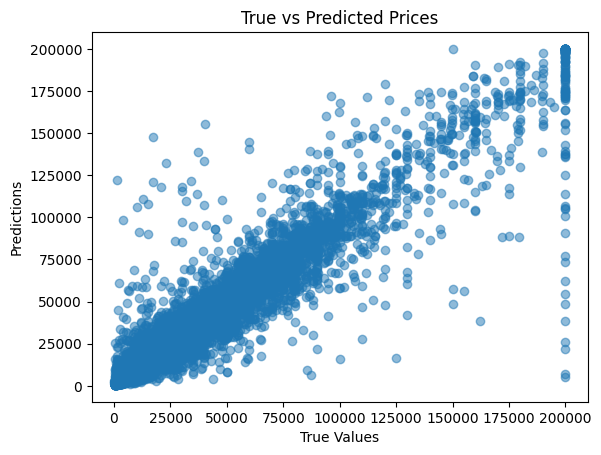

In [ ]:
# Fit the model on the training data
rf.fit(X_train, y_train)

# Make predictions on the validation set
y_pred = rf.predict(X_val)

# Plot true vs predicted prices
plt.scatter(y_val, y_pred, alpha=0.5)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Prices')
plt.show()


In [ ]:
import pandas as pd

# Create a DataFrame with true and predicted values
true_vs_predicted_df = pd.DataFrame({
    'True Prices': y_val,
    'Predicted Prices': y_pred
})

true_vs_predicted_df


,True Prices,Predicted Prices
356477,18890,17238.688333
78658,16671,17303.190000
140995,53458,38828.118405
14618,5950,7613.430000
244355,1895,2134.710000
...,...,...
318632,31995,27496.820000
226675,11250,8607.490000
89089,6139,6506.860000
300693,6995,12466.108333


## Feature Importance

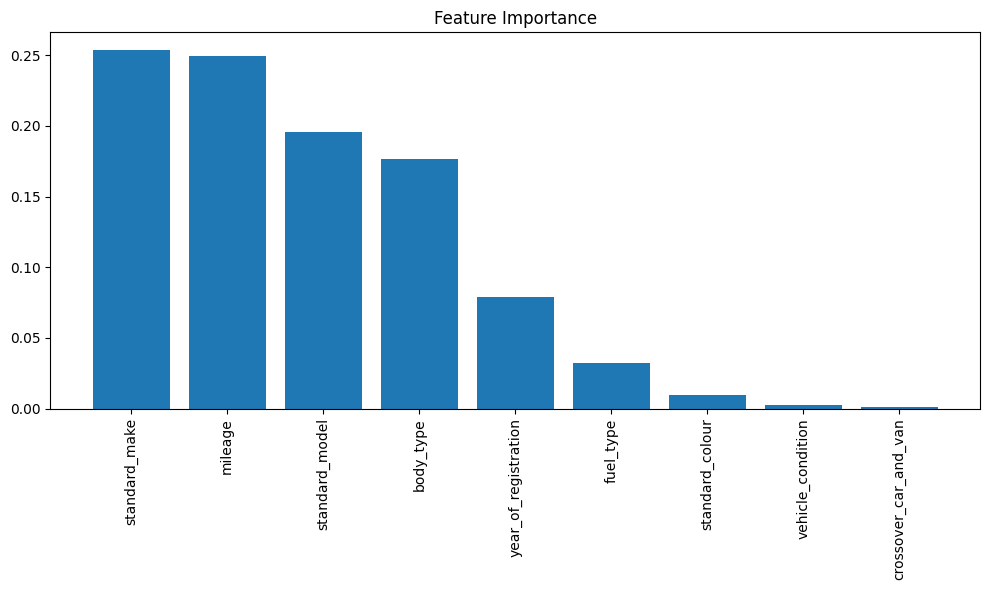

In [ ]:
import numpy as np

importances = rf.feature_importances_
sorted_indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance")
plt.bar(range(X_train.shape[1]), importances[sorted_indices], align='center')
plt.xticks(range(X_train.shape[1]), X_train.columns[sorted_indices], rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Create a DataFrame with feature names and their importance scores
feature_importances_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# Sort the DataFrame by importances
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

feature_importances_df


,Feature,Importance
2,standard_make,0.253550
0,mileage,0.249219
3,standard_model,0.195995
6,body_type,0.176857
5,year_of_registration,0.079161
8,fuel_type,0.032420
1,standard_colour,0.009347
4,vehicle_condition,0.002180
7,crossover_car_and_van,0.001269


## Model Output Space Analysis:

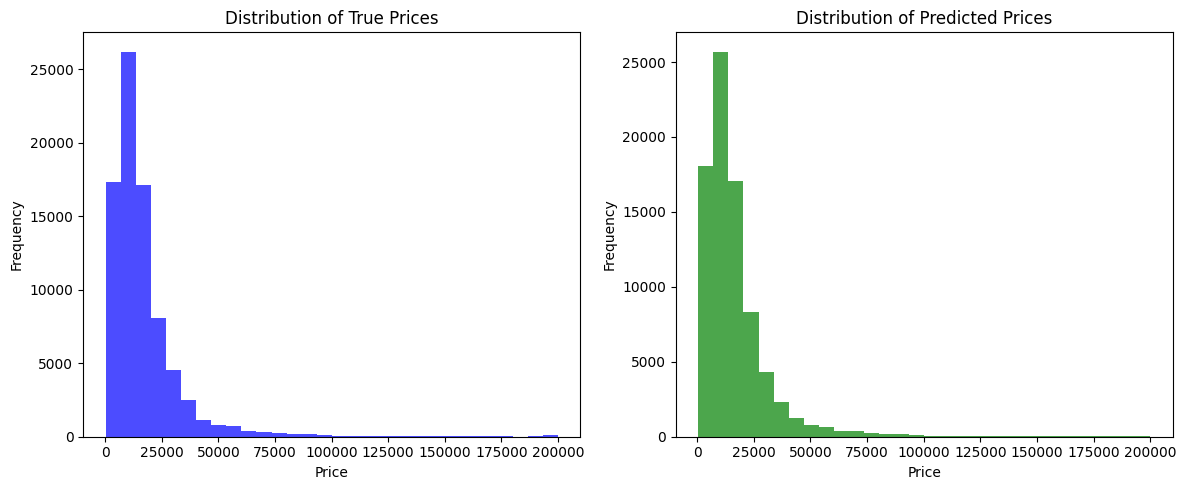

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(y_val, bins=30, color='blue', alpha=0.7, label='True Values')
plt.title('Distribution of True Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(y_pred, bins=30, color='green', alpha=0.7, label='Predicted Values')
plt.title('Distribution of Predicted Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Define the bins based on the range of prices
bins = np.linspace(min(y_val.min(), y_pred.min()), max(y_val.max(), y_pred.max()), 31)

# Compute the frequency for each bin for both true and predicted values
true_hist, _ = np.histogram(y_val, bins=bins)
pred_hist, _ = np.histogram(y_pred, bins=bins)

# Convert the frequencies to a DataFrame
df = pd.DataFrame({
    'Price Range Start': bins[:-1],
    'Price Range End': bins[1:],
    'True Values Count': true_hist,
    'Predicted Values Count': pred_hist
})

df


,Price Range Start,Price Range End,True Values Count,Predicted Values Count
0,200.0,6860.0,17374,16864
1,6860.0,13520.0,26218,25879
2,13520.0,20180.0,17114,17510
3,20180.0,26840.0,8073,8668
4,26840.0,33500.0,4523,4457
5,33500.0,40160.0,2486,2335
6,40160.0,46820.0,1122,1244
7,46820.0,53480.0,810,789
8,53480.0,60140.0,698,659
9,60140.0,66800.0,356,403


In [ ]:
!pip install shap


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.9/547.9 kB 9.0 MB/s eta 0:00:00


### Global and Local Explanations with SHAP

In [ ]:
import shap
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# X = data[['registration_year_squared', 'year_of_registration', 'body_type', 'standard_model', 'crossover_car_and_van', 'fuel_type']]
# y = data['price']

# Assuming you've already trained the Random Forest model
# model_rf = RandomForestRegressor(n_estimators=100)
# model_rf.fit(X, y)

# Create the SHAP explainer and compute SHAP values
explainer = shap.TreeExplainer(model_rf)
shap_values = explainer.shap_values(X)

# Global Explanation
shap.summary_plot(shap_values, X)

# Local Explanation for the first instance
shap.initjs()
shap.force_plot(explainer.expected_value[0], shap_values[0,:], X.iloc[0,:])


Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


### Partial Dependency Plots

In [ ]:
import numpy as np

def compute_pdp(model, X, feature, grid_points=100):
    """Compute Partial Dependency for a feature."""
    # Store original feature values
    original_values = X[feature].copy()

    # Create grid of values for the feature of interest
    grid = np.linspace(X[feature].min(), X[feature].max(), grid_points)

    # Calculate predictions for each grid value
    pdp_values = []
    for value in grid:
        X[feature] = value
        predictions = model.predict(X)
        pdp_values.append(predictions.mean())

    # Restore original feature values
    X[feature] = original_values

    return grid, pdp_values


In [ ]:
import plotly.graph_objects as go

# Assuming you've already trained the Random Forest model
model_rf = RandomForestRegressor(n_estimators=100)
model_rf.fit(X, y)

# Compute PDP for 'registration_year_squared'
grid, pdp_values = compute_pdp(model_rf, X, 'registration_year_squared')

# Plot using plotly
fig = go.Figure(data=[
    go.Scatter(x=grid, y=pdp_values, mode='lines', name='PDP')
])

fig.update_layout(title='Partial Dependence of registration_year_squared',
                   xaxis_title='registration_year_squared',
                   yaxis_title='Partial Dependence')
fig.show()
